---
tags: [algorithm, oracle-based]
---

# Introduction to Grover search

Grover search finds a marked item in an unstructured search space by
amplifying its probability amplitude {cite:p}`10.1145/237814.237866`. For a
search space of size $N$ with one marked item, it needs $O(\sqrt{N})$ oracle
queries instead of the $O(N)$ queries required by exhaustive classical search.

This notebook uses Qamomile's built-in `grover_search` and
`grover_iteration_count` functions. We search a four-qubit register for the
marked state $|0101\rangle$ and use one additional qubit inside the phase
oracle, giving a five-qubit circuit. Finally, we compare histograms of the
search-register probabilities before and after amplitude amplification.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
# Import numerical, plotting, simulator, and Qamomile utilities.
import math
import os

import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## Algorithm

Let $x_\star\in\{0,1\}^n$ be one marked $n$-qubit target state, and let
$N=2^n$ be the size of the search space. Define $f(x)$ to be one only when
$x=x_\star$ and zero otherwise. The corresponding phase oracle encodes this
predicate as a relative phase:

$$
O_f|x\rangle = (-1)^{f(x)}|x\rangle.
$$

The oracle therefore changes $|x_\star\rangle$ to
$-|x_\star\rangle$ while leaving every other basis state unchanged. A phase
alone does not change a measurement probability. Grover search combines the
phase oracle with a reflection about the uniform superposition so that the
target-state amplitude grows.

:::{note}
**What is an oracle?**

An oracle in a quantum algorithm is a reversible quantum operation that determines whether an input satisfies a condition. The algorithm treats it as a black box: it uses the oracle's behavior without depending on its internal implementation. This does not mean that an implementation is unnecessary; the actual oracle circuit must be constructed for each search problem. Grover search uses a phase oracle, which encodes the decision by changing the sign of matching states instead of writing the result to a separate qubit. Applying the oracle once counts as one oracle query.
:::

### Step 1: Prepare the Uniform Superposition

Starting from the $n$-qubit state $|0\rangle^{\otimes n}$, Hadamard gates
prepare

$$
|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}
= \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}|x\rangle,
\qquad N=2^n.
$$

For a single marked target, define
$|\mathrm{good}\rangle=|x_\star\rangle$ and let
$|\mathrm{bad}\rangle$ be the normalized superposition of the other $N-1$
basis states:

$$
|\mathrm{bad}\rangle
= \frac{1}{\sqrt{N-1}}
\sum_{x\ne x_\star}|x\rangle.
$$

The initial state can then be written as

$$
|s\rangle
= \cos\theta|\mathrm{bad}\rangle
+ \sin\theta|\mathrm{good}\rangle,
\qquad
\theta=\arcsin\frac{1}{\sqrt{N}}.
$$

### Step 2: Mark the Target State with a Phase Oracle

The phase oracle applies the sign change

$$
O_f|x_\star\rangle=-|x_\star\rangle.
$$

The oracle is the problem-dependent part of Grover search. Its circuit must
mark only the target state (or, more generally, the states satisfying the
search predicate) and uncompute any temporary workspace before it returns.

### Step 3: Reflect about the Uniform Superposition

After the oracle, the diffusion operator

$$
D=2|s\rangle\langle s|-I
$$

reflects all amplitudes about their mean. One Grover iteration is therefore

$$
G=DO_f.
$$

In the two-dimensional plane spanned by $|\mathrm{bad}\rangle$ and
$|\mathrm{good}\rangle$, the oracle and diffusion reflections combine into a
rotation by $2\theta$ toward the target state.

### Step 4: Repeat the Grover Iteration

After $r$ iterations, the search-register state is

$$
G^r|s\rangle
= \cos((2r+1)\theta)|\mathrm{bad}\rangle
+ \sin((2r+1)\theta)|\mathrm{good}\rangle.
$$

Thus, the probability of measuring the target state is

$$
P_r=\sin^2((2r+1)\theta).
$$

The first maximum of $P_r$ occurs when the accumulated angle $(2r+1)\theta$
is closest to the optimal angle $\pi/2$. Qamomile's
`grover_iteration_count(n, 1)` helper automatically calculates a suitable
integer iteration count from the number of search qubits. Additional
iterations can rotate amplitude away from the target state.

### Step 5: Measure the Search Register

Measuring after the chosen number of iterations returns $x_\star$ with high
probability. The built-in `qmc.grover_search` function performs the
uniform-state preparation and the requested oracle-and-diffusion iterations.
The caller supplies the problem-dependent phase oracle and measures the
returned search register.

In summary, Grover search follows these steps:

1. Allocate $n$ search qubits and initialize them in $|0\rangle^{\otimes n}$.
2. Apply Hadamard gates to obtain the uniform superposition over all $N=2^n$
   states.
3. Apply a phase oracle that flips the phase of $|x_\star\rangle$.
4. Apply the diffusion operator to amplify the target-state amplitude.
5. Repeat the oracle and diffusion for the chosen number of iterations.
6. Measure the search register.

## Implementation: `grover_search`

### Problem Settings

We now instantiate the general algorithm with four search qubits, so
$N=2^4=16$, and mark only $|0101\rangle$. Before Grover search, every state
in the uniform superposition has probability $1/16$. For one marked state,
`grover_iteration_count(4, 1)` gives three iterations. The ideal
marked-state probability after those iterations is approximately $0.9613$.
Basis-state labels use the conventional $|q_3q_2q_1q_0\rangle$ display order,
so `search[0]` is the rightmost, least-significant bit.

A fifth qubit serves as the oracle auxiliary qubit. It starts and ends every
oracle query in $|0\rangle$, so the same physical qubit can be reused in each
Grover iteration.

In [3]:
# Define the concrete search problem and sampling settings.
SEARCH_QUBITS = 4
NUM_MARKED = 1
MARKED_STATE = "0101"
ITERATIONS = qmc.grover_iteration_count(SEARCH_QUBITS, NUM_MARKED)

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
SHOTS = 512 if docs_test_mode else 4096
SAMPLER_SEED = 42

theta = math.asin(math.sqrt(NUM_MARKED / 2**SEARCH_QUBITS))
ideal_marked_probability = math.sin((2 * ITERATIONS + 1) * theta) ** 2

print("search qubits:", SEARCH_QUBITS)
print("marked state:", MARKED_STATE)
print("Grover iterations:", ITERATIONS)
print("ideal marked-state probability:", f"{ideal_marked_probability:.6f}")

assert ITERATIONS == 3
assert ideal_marked_probability > 0.96

search qubits: 4
marked state: 0101
Grover iterations: 3
ideal marked-state probability: 0.961319


### Phase Oracle

The oracle below uses the same multi-controlled-X phase-marking pattern as the
Grover tests. The difference is that this example uses a dedicated auxiliary
target. The X and H gates prepare it in $|-\rangle$, the multi-controlled X
marks `|0101>` by phase kickback, and the final H and X restore the auxiliary
qubit to $|0\rangle$. X gates around the phase-kickback block map the zero bits
of `0101` to one and then restore the original basis labels.

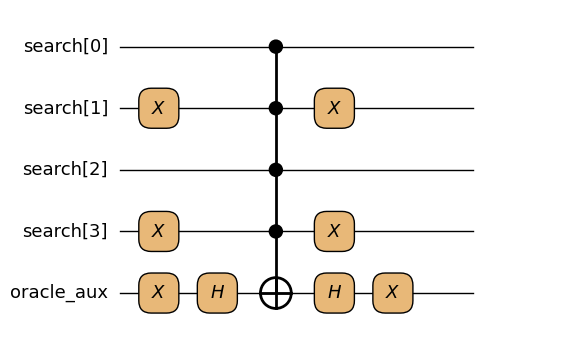

In [4]:
# Mark |0101> with a reusable phase-kickback auxiliary qubit.
@qmc.qkernel
def oracle_operator(
    search: qmc.Vector[qmc.Qubit],
) -> qmc.Vector[qmc.Qubit]:
    oracle_aux = qmc.qubit(name="oracle_aux")

    # Map |q3 q2 q1 q0> = |0101> to |1111>.
    search[1] = qmc.x(search[1])
    search[3] = qmc.x(search[3])

    # Prepare the auxiliary qubit in |->.
    oracle_aux = qmc.x(oracle_aux)
    oracle_aux = qmc.h(oracle_aux)

    # Flip the auxiliary qubit only when all search qubits are one.
    multi_controlled_x = qmc.control(
        qmc.x,
        num_controls=search.shape[0],
    )
    search, oracle_aux = multi_controlled_x(search, oracle_aux)

    # Return the auxiliary qubit to |0> so it can be reused.
    oracle_aux = qmc.h(oracle_aux)
    oracle_aux = qmc.x(oracle_aux)

    # Restore the original computational-basis labels.
    search[1] = qmc.x(search[1])
    search[3] = qmc.x(search[3])
    return search


oracle_operator.draw(search=SEARCH_QUBITS, fold_loops=False)

### Search Kernels

`uniform_superposition` captures the distribution immediately before the
first oracle query. It allocates the same four search qubits and one auxiliary
qubit as the full example, but only the search register is placed in uniform
superposition and measured.

`grover_search_example` passes `oracle_operator` and the iteration-count handle
to `qmc.grover_search`. We keep `iterations` as a `qmc.UInt` structural input
and bind it while transpiling. This keeps one oracle body inside the loop, so
its auxiliary qubit is reused across all three iterations instead of allocating
a separate auxiliary qubit for each unrolled Python call.

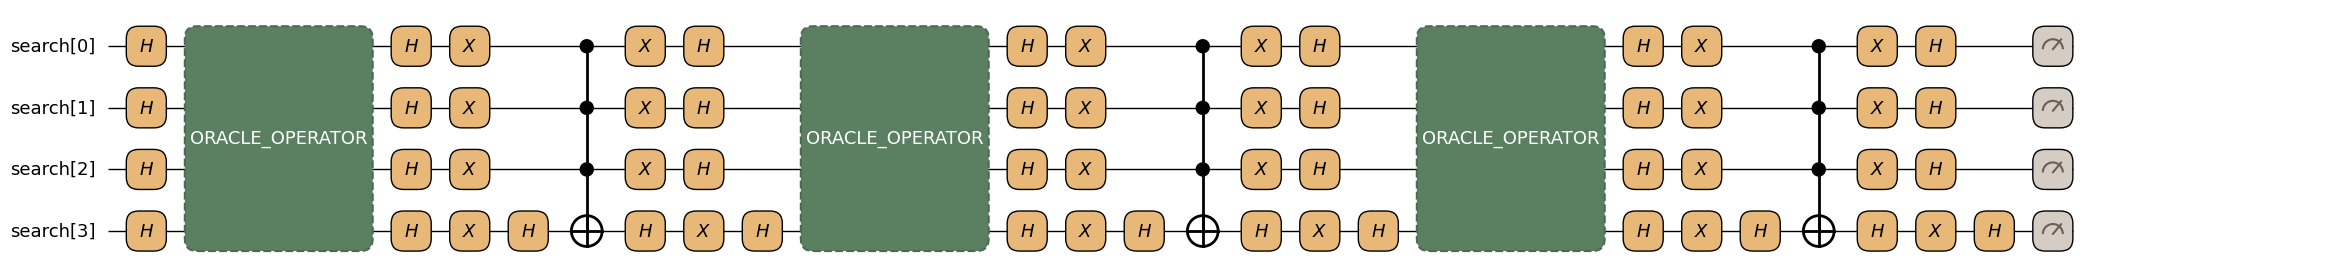

In [5]:
# Measure the uniform search-register distribution before amplitude amplification.
@qmc.qkernel
def uniform_superposition() -> qmc.Vector[qmc.Bit]:
    search = qmc.qubit_array(SEARCH_QUBITS, name="search")
    _oracle_aux = qmc.qubit(name="oracle_aux")
    search = qmc.h(search)
    return qmc.measure(search)


# Repeat the Grover iterations using the precomputed iteration count.
@qmc.qkernel
def grover_search_example(
    iterations: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    search = qmc.qubit_array(SEARCH_QUBITS, name="search")
    search = qmc.grover_search(search, oracle_operator, iterations)
    return qmc.measure(search)


grover_search_example.draw(iterations=ITERATIONS, fold_loops=False)

In [6]:
# Confirm that the search register and oracle auxiliary use five qubits in total.
search_resources = grover_search_example.estimate_resources(
    inputs={"iterations": ITERATIONS}
).simplify()
print("total circuit qubits:", search_resources.qubits)
assert search_resources.qubits == SEARCH_QUBITS + 1

total circuit qubits: 5


## Execution Result

We transpile both kernels to Qiskit and sample them with identical shot counts.
The first histogram should be nearly uniform. In the second histogram,
`|0101>` should dominate after three Grover iterations.

### Run the Quantum Circuits

In [7]:
# Transpile and sample one kernel with a deterministic simulator seed.
def sample_kernel(kernel, *, bindings: dict[str, int] | None = None, seed: int):
    executable = transpiler.transpile(kernel, bindings=bindings or {})
    executor = transpiler.executor(
        backend=AerSimulator(
            seed_simulator=seed,
            max_parallel_threads=1,
        )
    )
    return executable.sample(executor, shots=SHOTS).result()


before_result = sample_kernel(uniform_superposition, seed=SAMPLER_SEED)
after_result = sample_kernel(
    grover_search_example,
    bindings={"iterations": ITERATIONS},
    seed=SAMPLER_SEED + 1,
)

### Plot and Inspect the Results

We convert both sample results to search-register probabilities, then compare
the distributions before and after amplitude amplification.

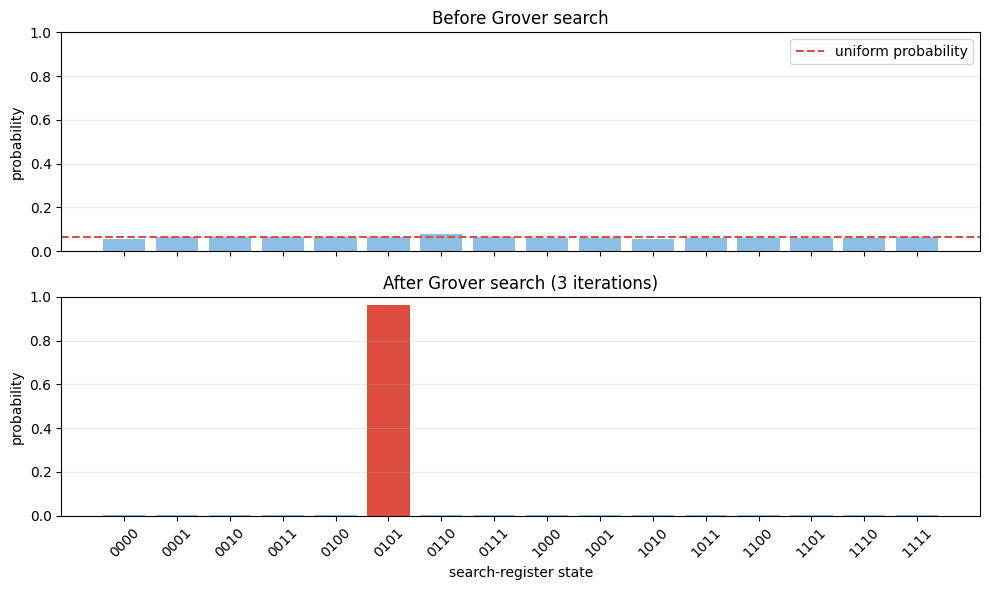

sampled marked-state probability: 0.961182
ideal marked-state probability: 0.961319


In [8]:
# Convert LSB-first measurement tuples to conventional |q3 q2 q1 q0> labels.
def state_probabilities(sample_result) -> dict[str, float]:
    return {
        "".join(str(bit) for bit in reversed(state)): count / sample_result.shots
        for state, count in sample_result.results
    }


before_probabilities = state_probabilities(before_result)
after_probabilities = state_probabilities(after_result)

# Display basis states with q0 as the rightmost, least-significant bit.
basis_states = [
    format(index, f"0{SEARCH_QUBITS}b") for index in range(2**SEARCH_QUBITS)
]
before_values = [before_probabilities.get(state, 0.0) for state in basis_states]
after_values = [after_probabilities.get(state, 0.0) for state in basis_states]

# Compare search-register probabilities before and after Grover search.
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
axes[0].bar(basis_states, before_values, color="#8DBFE6")
axes[0].axhline(
    1 / 2**SEARCH_QUBITS,
    color="#DB4D3F",
    linestyle="--",
    label="uniform probability",
)
axes[0].set_title("Before Grover search")
axes[0].set_ylabel("probability")
axes[0].legend()

bar_colors = ["#DB4D3F" if state == MARKED_STATE else "#8DBFE6" for state in basis_states]
axes[1].bar(basis_states, after_values, color=bar_colors)
axes[1].set_title(f"After Grover search ({ITERATIONS} iterations)")
axes[1].set_xlabel("search-register state")
axes[1].set_ylabel("probability")
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Verify the uniform input and the amplified marked state.
uniform_probability = 1 / 2**SEARCH_QUBITS
assert all(abs(value - uniform_probability) < 0.06 for value in before_values)
assert max(after_probabilities, key=after_probabilities.get) == MARKED_STATE
assert after_probabilities[MARKED_STATE] > 0.85

print("sampled marked-state probability:", f"{after_probabilities[MARKED_STATE]:.6f}")
print("ideal marked-state probability:", f"{ideal_marked_probability:.6f}")

The first histogram is close to the uniform value $1/16$ for every state.
After three oracle-and-diffusion rounds, almost all probability is concentrated
on `|0101>`, close to the ideal value predicted by
$\sin^2((2r+1)\theta)$. Sampling introduces small deviations from that exact
probability.

The auxiliary qubit is not included in either histogram. It starts and ends
each oracle query in $|0\rangle$ and exists only to kick the oracle phase back
onto the four-qubit search register.

## Resource Estimation

Each Grover iteration calls the phase oracle exactly once. Therefore, the
number of phase-oracle queries is the iteration count returned by
`grover_iteration_count`. To visualize the quadratic speedup, we can evaluate
this function directly for several search-register widths; no circuit-level
resource estimate is needed.

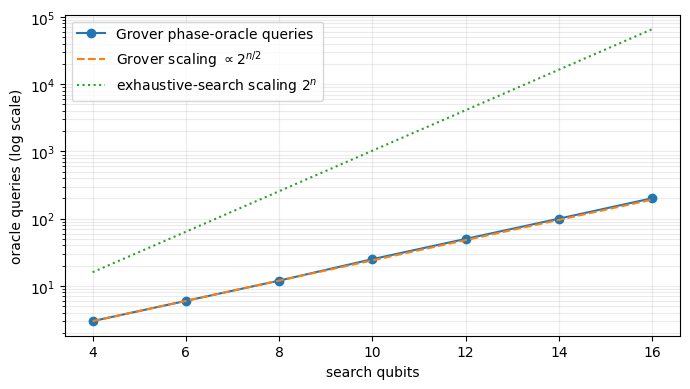

In [9]:
# Calculate one phase-oracle query count for each search-register width.
RESOURCE_SEARCH_QUBITS = [4, 6, 8, 10, 12, 14, 16]
grover_query_counts = [
    qmc.grover_iteration_count(num_search_qubits, 1)
    for num_search_qubits in RESOURCE_SEARCH_QUBITS
]

grover_scaling_reference = [
    grover_query_counts[0]
    * 2 ** ((num_search_qubits - RESOURCE_SEARCH_QUBITS[0]) // 2)
    for num_search_qubits in RESOURCE_SEARCH_QUBITS
]
exhaustive_search_reference = [
    2**num_search_qubits for num_search_qubits in RESOURCE_SEARCH_QUBITS
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    grover_query_counts,
    marker="o",
    label="Grover phase-oracle queries",
)
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    grover_scaling_reference,
    linestyle="--",
    label=r"Grover scaling $\propto 2^{n/2}$",
)
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    exhaustive_search_reference,
    linestyle=":",
    label=r"exhaustive-search scaling $2^n$",
)
ax.set_xlabel("search qubits")
ax.set_ylabel("oracle queries (log scale)")
ax.set_xticks(RESOURCE_SEARCH_QUBITS)
ax.set_yscale("log", base=10)
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.tight_layout()
plt.show()

assert grover_query_counts == [3, 6, 12, 25, 50, 100, 201]
assert all(
    later > earlier
    for earlier, later in zip(grover_query_counts, grover_query_counts[1:])
)
assert all(
    grover_queries < exhaustive_queries
    for grover_queries, exhaustive_queries in zip(
        grover_query_counts, exhaustive_search_reference
    )
)

With one marked state, `grover_iteration_count(n, 1)` gives

$$
r(n)=\left\lfloor\frac{\pi}{4}\sqrt{2^n}\right\rfloor
=\Theta(2^{n/2})
$$

queries. For one marked state,
$\theta=\arcsin(1/\sqrt{2^n})\approx1/\sqrt{2^n}$. The leading factor
$\pi/4$ comes from dividing the optimal angle $\pi/2$ by the $2\theta$
rotation per Grover iteration. The logarithmic plot compares Grover search's
$\Theta(2^{n/2})$ queries with the $\Theta(2^n)$ queries of classical
exhaustive search. It therefore demonstrates the quadratic speedup over
classical exhaustive search in terms of oracle-query complexity.

:::{note}
This comparison treats each application of the phase oracle as one query and does not account for the oracle's internal circuit. A concrete phase oracle can require multiple gates and auxiliary qubits per application. Therefore, designing an oracle appropriate to the problem is important in Grover search.
:::

## Summary

In this notebook, we implemented Grover search with Qamomile's
`qmc.grover_search` and found one marked state in a 16-element search space.

- Grover search is a quantum algorithm that finds a target state by using a
  phase oracle and diffusion operator to amplify the marked state's
  probability amplitude.
- `qmc.grover_iteration_count()` can calculate the optimal number of Grover
  iterations when one state is marked.
- `qmc.grover_search` prepares the uniform superposition and applies the phase
  oracle followed by the diffusion operator in every iteration.
- The oracle is problem-dependent: a different predicate or marked bit string
  requires a corresponding phase-oracle implementation.